### Binary Traffic Sign Classification

This is our first notebook on neural networks. We will start by building a simple neural network that will help us to classify two types of traffic signs. The signs used in this lesson are a processed subset from the famous German Traffic Sign Recognition Database (GTSRB) that can be downloaded [here]().

In [1]:
import os
import cv2
from time import time
import numpy as np
from sklearn.utils import shuffle

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 6]

#### Data Loading

Let's now load the data to see what we are dealing with.

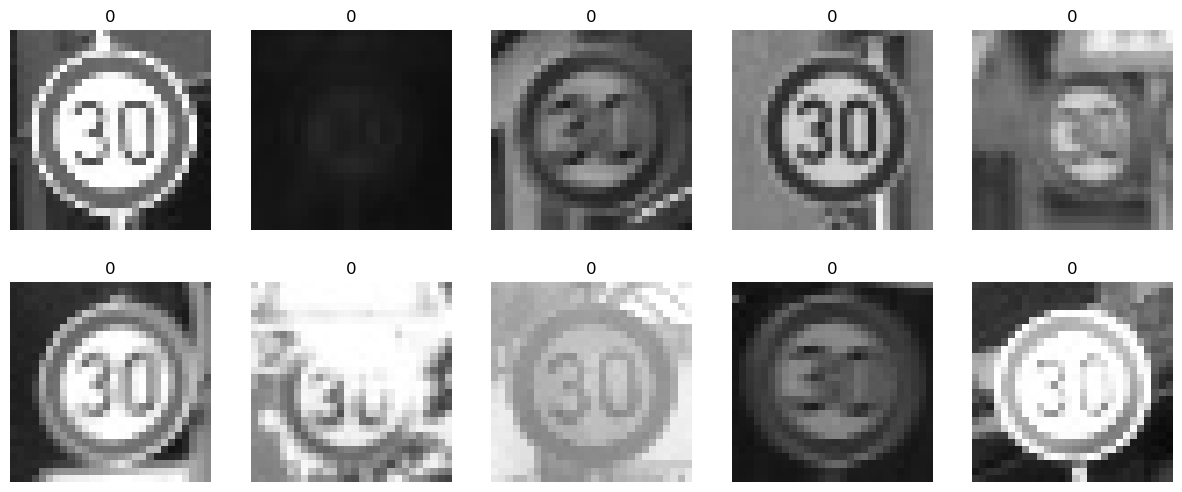

In [19]:
folder = 'data/subset_homework'

# Load traffic sign class 0
fnames_0 = os.listdir(os.path.join(folder, 'class_id_0'))
images_0 = [cv2.imread(os.path.join(folder, 'class_id_0', f), cv2.IMREAD_UNCHANGED) for f in fnames_0]
labels_0 = [0] * len(images_0)

for cnt, idx in enumerate(np.random.randint(0, len(images_0), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_0[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_0[idx]), plt.axis(False)

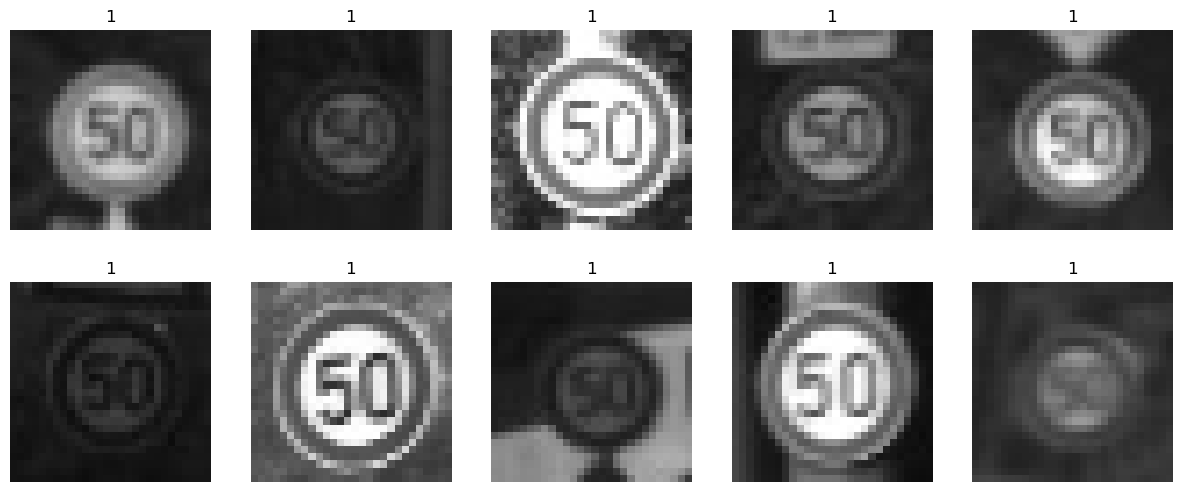

In [20]:
# Load traffic sign class 1
fnames_1 = os.listdir(os.path.join(folder, 'class_id_1'))
images_1 = [cv2.imread(os.path.join(folder, 'class_id_1', f), cv2.IMREAD_UNCHANGED) for f in fnames_1]
labels_1 = [1] * len(images_1)

for cnt, idx in enumerate(np.random.randint(0, len(images_1), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_1[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_1[idx]), plt.axis(False)

In [21]:
print('Num samples class_0', len(images_0))
print('Num samples class_1', len(images_1))

Num samples class_0 2220
Num samples class_1 2250


#### Prepare Input Data

To train our neural network model, we have to prepare the data to the format the the model actually expects. In our case, this will be numpy arrays.

In [22]:
# Put both classes together and shuffle the data
images = images_0 + images_1
labels = labels_0 + labels_1
images, labels = shuffle(images, labels)

images = np.array(images)
labels = np.array(labels)

print('Images', images.shape)
print('Labels', labels.shape)

Images (4470, 28, 28)
Labels (4470,)


But now we have a problem. We cannot just feed the image to a neuron since the neuron inputs are flat (one dimensional). On the other hand, the images are 2D matrices. Therefore, we need to "flatten" the images to a one dimensional vector of pixels.

Or, you know, just let make use of our friend numpy :-)

In [23]:
start = time()
pixels = np.array([image.flatten() for image in images])/255
stop = time()

print('Shape', pixels.shape)
print('Elapsed time', stop - start)

Shape (4470, 784)
Elapsed time 0.04083061218261719


Before the training, let's again have a look at some raqndom samples from our dataset.

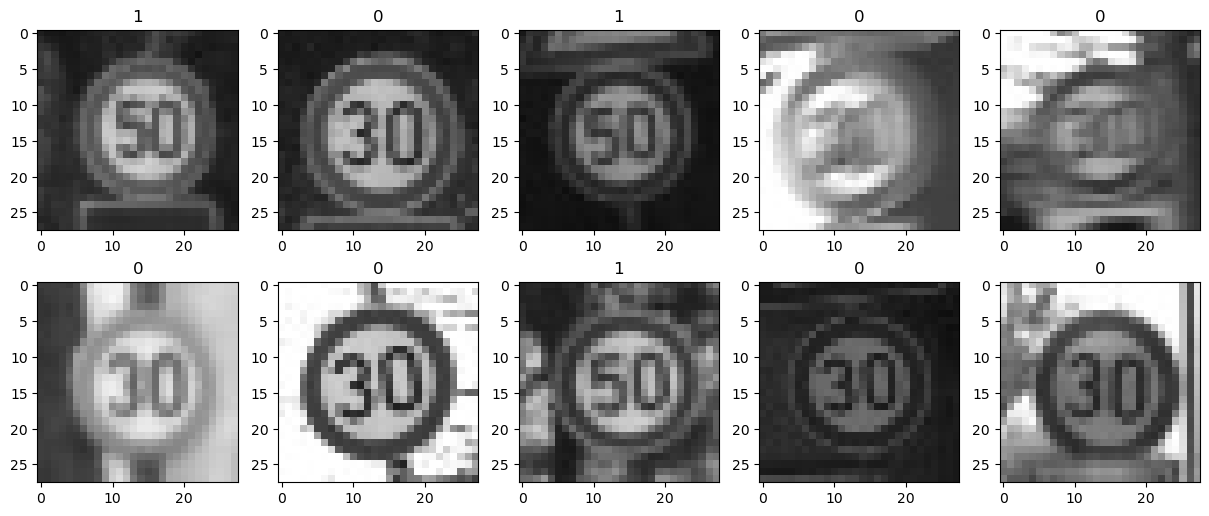

In [24]:
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)):    
    plt.subplot(2,5,cnt+1)
    plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels[idx])

#### Building the Neural Network

Let's now build our first (and yes, very simple) neural network using Tensorflow. For that, we will need a couple of new imports.

In [25]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input

The following netowork will consist of only one single neuron. It is a very tiny network (not even a network, strictly speaking :-) ) and yet it can be quite powerful.

In [26]:
inputs = Input(shape=(pixels.shape[1],))
outputs = Dense(1, activation="linear")(inputs)
model = Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           785 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
tf.keras.utils.plot_model(model, to_file="model.png", show_shapes=True, show_layer_names=True)

Before starting the training, we have to compile the model. During the compilation, we indicate what optimizer we want to use and what loss should be applied for the minimization process.

In [27]:
model.compile(optimizer ='adam', loss = 'mean_squared_error')

And let's train :-)

In [28]:
history = model.fit(pixels, labels, epochs=10, batch_size=32)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3446
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2368
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1941
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1663
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1441
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1329
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1189
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1115
Epoch 9/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1045
Epoch 10/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0996


(Text(0.5, 0, 'epoch'), Text(0, 0.5, 'loss'))

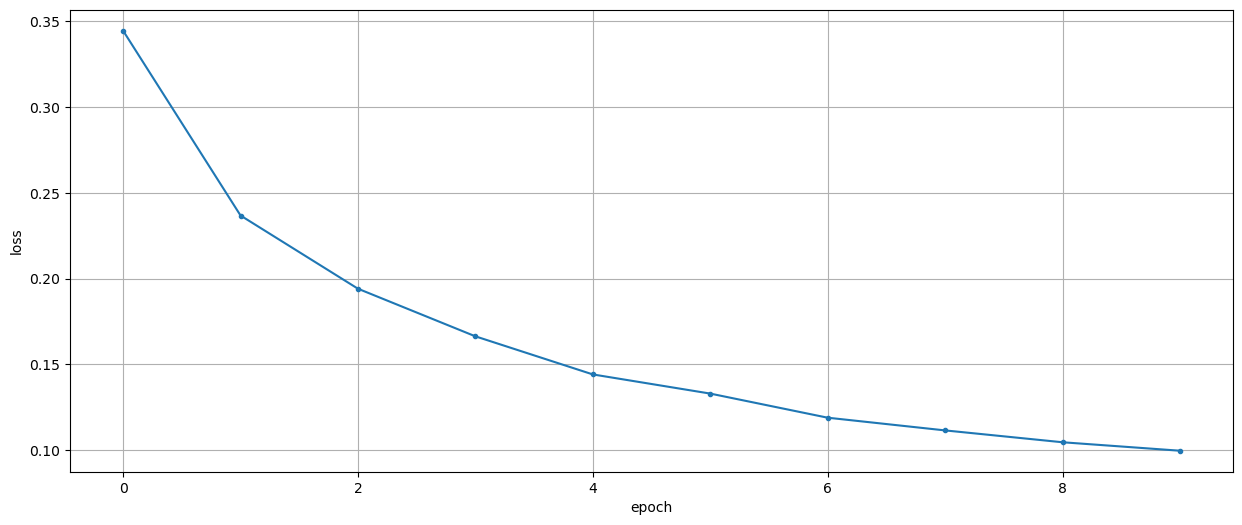

In [29]:
# Plot training history
h = history.history
epochs = range(len(h['loss']))
plt.plot(epochs, h['loss'], '.-'), plt.grid(True)
plt.xlabel('epoch'), plt.ylabel('loss')

[0.3980312] [0.3980312]


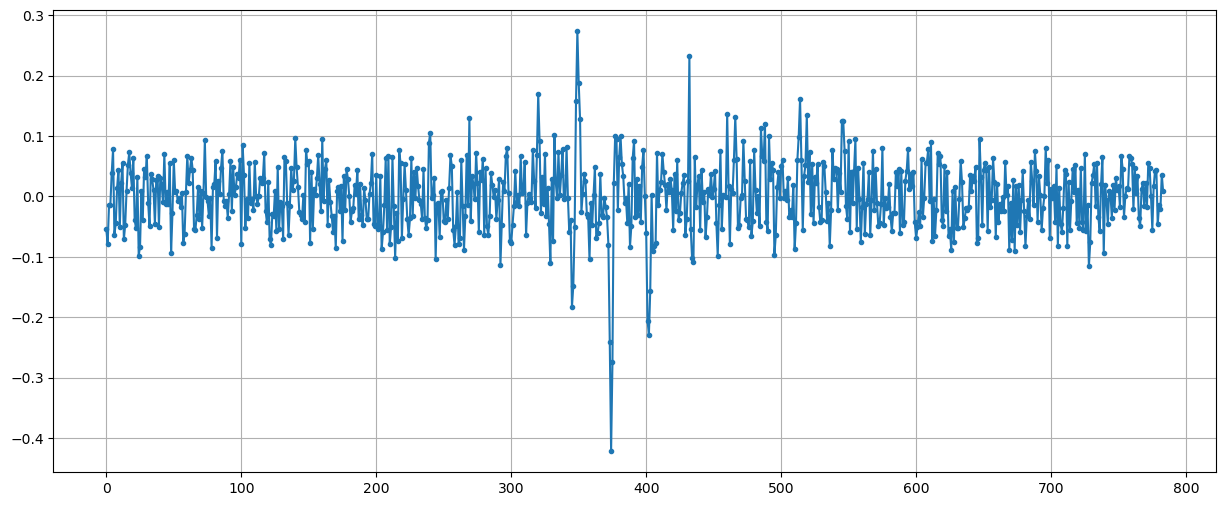

In [30]:
# Let's also have a looks at the learnt weights
plt.plot(model.layers[1].weights[0].numpy(), '.-'), plt.grid(True)
print(model.layers[1].weights[1].numpy(), model.layers[1].bias.numpy())

#### Performance Evaluation

Once our model is trained, we will can run it on our images to see how it performs (inference).

In [31]:
idx = 50
pred = model.predict(pixels[idx:idx+1, ...])
print(pred, labels[idx])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
[[0.7713086]] 1


In [32]:
# Run it on the entire dataset
predictions = model.predict(pixels).squeeze()
predictions = predictions > 0.5

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [33]:
correct = 0
for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct = correct + 1

print('Accuracy', correct/len(labels))

Accuracy 0.9203579418344519


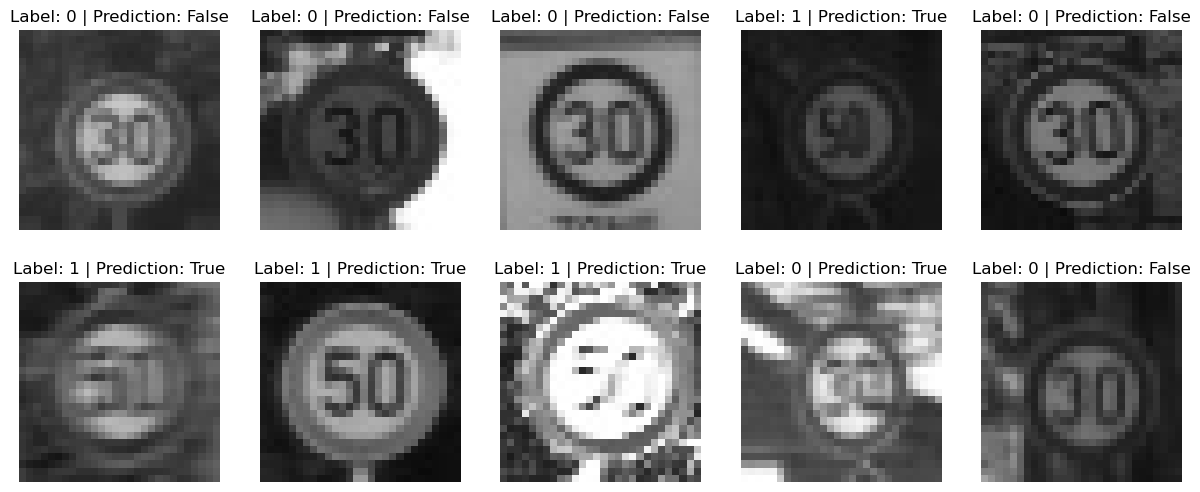

In [34]:
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)): 
    plt.subplot(2,5,cnt+1), plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title('Label: ' + str(labels[idx]) + ' | Prediction: ' + str(predictions[idx]))
    plt.axis(False)

In [37]:
#Instead of a single neuron, let's use a multi-layer perceptron (MLP)

inputs = Input(shape=(pixels.shape[1],))
x = Dense(128, activation="relu")(inputs)
x = Dense(64, activation="relu")(x)
outputs = Dense(1, activation="sigmoid")(x)  # Use sigmoid for binary classification

model = Model(inputs, outputs)
#model.summary()

#compile
model.compile(optimizer ='adam', loss = 'mean_squared_error')

#train
history = model.fit(pixels, labels, epochs=10, batch_size=32)

# Run it on the entire dataset
predictions = model.predict(pixels).squeeze()
predictions = predictions > 0.5

#calculate accuracy
correct = 0
for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct = correct + 1

print('Accuracy', correct/len(labels))

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2205
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1424
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0997
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0760
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0613
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0566
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0559
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0496
Epoch 9/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0454
Epoch 10/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0389
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy 0.9606263982102908


In [39]:
# Use Dropout to prevent overfitting
from tensorflow.keras.layers import Dropout

x = Dense(128, activation="relu")(inputs)
x = Dropout(0.5)(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.5)(x)

model = Model(inputs, outputs)
#model.summary()

#compile
model.compile(optimizer ='adam', loss = 'mean_squared_error')

#train
history = model.fit(pixels, labels, epochs=10, batch_size=32)

# Run it on the entire dataset
predictions = model.predict(pixels).squeeze()
predictions = predictions > 0.5

#calculate accuracy
correct = 0
for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct = correct + 1

print('Accuracy', correct/len(labels))

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0438
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0319
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0313
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0366
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0368
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0320
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0304
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0391
Epoch 9/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0271
Epoch 10/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0436
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy 0.9677852348993289


In [40]:
# Dropout showed the best occuracy so far. Let enhance and compile with appropriate Loss and Optimizer
from tensorflow.keras.layers import Dropout

x = Dense(128, activation="relu")(inputs)
x = Dropout(0.5)(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.5)(x)

model = Model(inputs, outputs)
#model.summary()

#compile
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

#train
history = model.fit(pixels, labels, epochs=10, batch_size=32)

# Run it on the entire dataset
predictions = model.predict(pixels).squeeze()
predictions = predictions > 0.5

#calculate accuracy
correct = 0
for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct = correct + 1

print('Accuracy', correct/len(labels))

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9671 - loss: 0.1006
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9676 - loss: 0.0938
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9544 - loss: 0.1256
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9727 - loss: 0.0850
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9723 - loss: 0.0868
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9783 - loss: 0.0663
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9532 - loss: 0.1355
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9763 - loss: 0.0687
Epoch 9/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9817 - loss: 0.0571
Epoch 10/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9821 - loss: 0.0486
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy 0.9914988814317673


In [41]:
#Let's enhance code above with different split

# Dropout showed the best occuracy so far. Let enhance and compile with appropriate Loss and Optimizer
from tensorflow.keras.layers import Dropout

x = Dense(128, activation="relu")(inputs)
x = Dropout(0.5)(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.5)(x)

model = Model(inputs, outputs)
#model.summary()

#compile
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

#train
history = model.fit(pixels, labels, epochs=20, batch_size=32, validation_split=0.2)

# Run it on the entire dataset
predictions = model.predict(pixels).squeeze()
predictions = predictions > 0.5

#calculate accuracy
correct = 0
for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct = correct + 1

print('Accuracy', correct/len(labels))

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9743 - loss: 0.0700 - val_accuracy: 0.9787 - val_loss: 0.0652
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9852 - loss: 0.0483 - val_accuracy: 0.9620 - val_loss: 0.0869
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9801 - loss: 0.0640 - val_accuracy: 0.9799 - val_loss: 0.0450
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9829 - loss: 0.0463 - val_accuracy: 0.9810 - val_loss: 0.0450
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9874 - loss: 0.0381 - val_accuracy: 0.9776 - val_loss: 0.0817
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9723 - loss: 0.0753 - val_accuracy: 0.9799 - val_loss: 0.0637
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9930 - loss: 0.0262 - val_accuracy: 0.9855 - val_loss: 0.0470
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9760 - loss: 0.0668 - val_accuracy: 0

# What is the maximum accuracy you can achieve?
## Maximum accuracy is 0.9914988814317673 for Dropout compiled with appropriate Loss and Optimizer